#  Projet 12 — Détection automatique de faux billets
## Organisation nationale de lutte contre le faux-monnayage (ONCFM)

**Objectif** : Construire un algorithme capable de différencier automatiquement les vrais des faux billets à partir de leurs caractéristiques géométriques.

**Données** : 1 500 billets (1 000 vrais, 500 faux) avec 6 dimensions géométriques.

**Modèles testés** : Régression logistique, K-Means, KNN, Random Forest.

---


## 1. Importation des bibliothèques et chargement des données


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuration pour de belles visualisations
plt.style.use('default')
sns.set_palette("husl")

# Chargement du dataset
df = pd.read_csv('billets.csv', sep=';')
print(f"Dataset chargé : {df.shape[0]} billets, {df.shape[1]} colonnes")
print("\nPremières lignes :")
df.head()

Dataset chargé : 1500 billets, 7 colonnes

Premières lignes :


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


## 2. Analyse descriptive des données

### 2.1 Répartition des billets (vrais / faux)


In [2]:
# Répartition vrais / faux
print("Répartition des billets :")
print(df['is_genuine'].value_counts())
print(f"\nRapport Vrais/Faux : {df['is_genuine'].sum()} / {(~df['is_genuine']).sum()}")
print(f"Pourcentage de faux billets : {(~df['is_genuine']).sum() / len(df) * 100:.1f}%")

Répartition des billets :
is_genuine
True     1000
False     500
Name: count, dtype: int64

Rapport Vrais/Faux : 1000 / 500
Pourcentage de faux billets : 33.3%


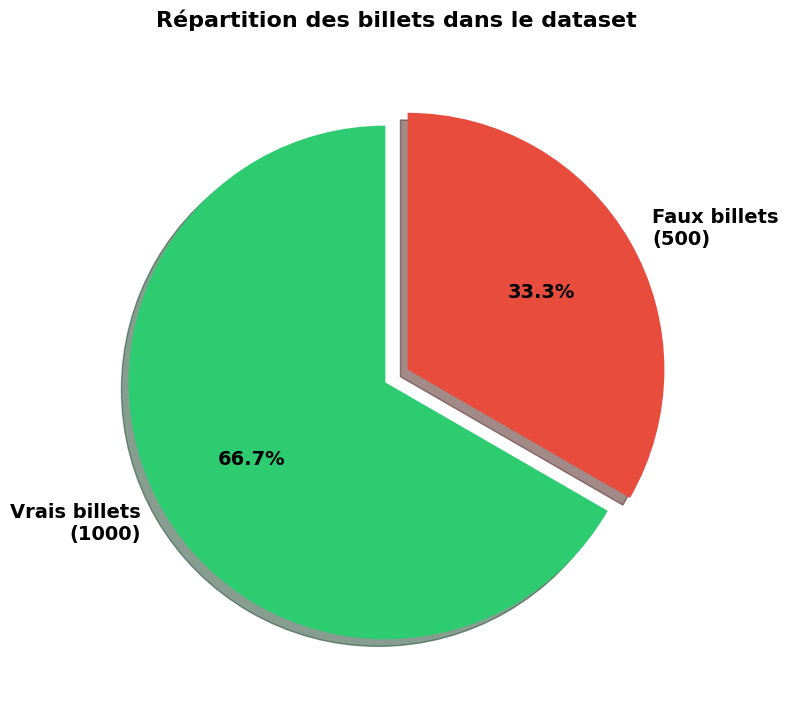

In [3]:
# Visualisation : Pie chart de la répartition
fig, ax = plt.subplots(figsize=(8, 8))
counts = df['is_genuine'].value_counts()
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

ax.pie([counts[True], counts[False]], 
       labels=['Vrais billets\n(1000)', 'Faux billets\n(500)'],
       colors=colors, autopct='%1.1f%%', startangle=90,
       explode=explode, shadow=True,
       textprops={'fontsize': 14, 'weight': 'bold'})

ax.set_title('Répartition des billets dans le dataset', 
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 2.2 Statistiques descriptives par groupe


In [4]:
# Statistiques descriptives par type de billet
features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
print("Statistiques descriptives par type de billet :\n")
stats_by_group = df.groupby('is_genuine')[features].describe().round(2)
print(stats_by_group)

Statistiques descriptives par type de billet :

           diagonal                                                        \
              count    mean   std     min     25%     50%     75%     max   
is_genuine                                                                  
False         500.0  171.90  0.31  171.04  171.69  171.91  172.09  173.01   
True         1000.0  171.99  0.30  171.04  171.79  171.99  172.20  172.92   

           height_left          ... margin_up        length                \
                 count    mean  ...       75%   max   count    mean   std   
is_genuine                      ...                                         
False            500.0  104.19  ...      3.47  3.91   500.0  111.63  0.62   
True            1000.0  103.95  ...      3.18  3.74  1000.0  113.20  0.36   

                                                    
               min     25%     50%     75%     max  
is_genuine                                          
False       109.49  1

### 2.3 Distributions des caractéristiques géométriques

Comparaison des distributions entre vrais et faux billets pour chaque variable.


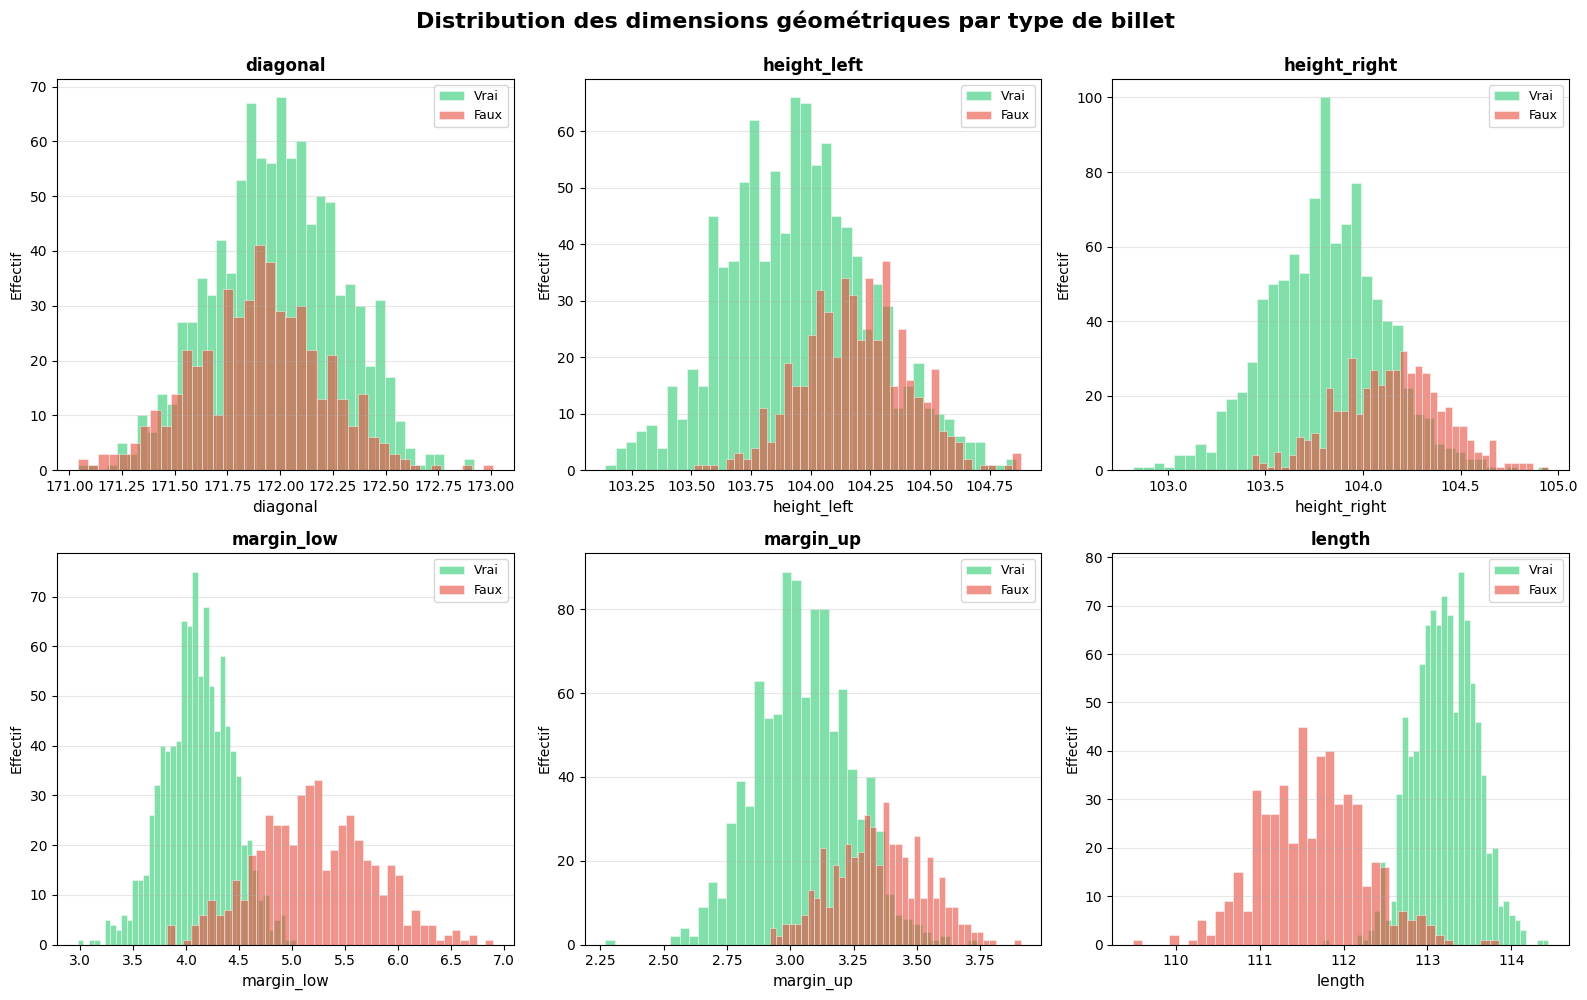

In [5]:
# Histogrammes des 6 caractéristiques par type de billet
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution des dimensions géométriques par type de billet', 
             fontsize=16, fontweight='bold', y=0.995)

colors_true = '#2ecc71'
colors_false = '#e74c3c'

for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    
    # Histogrammes superposés
    ax.hist(df.loc[df['is_genuine']==True, feat], 
            bins=40, alpha=0.6, color=colors_true, label='Vrai', 
            edgecolor='white', linewidth=0.5)
    ax.hist(df.loc[df['is_genuine']==False, feat], 
            bins=40, alpha=0.6, color=colors_false, label='Faux', 
            edgecolor='white', linewidth=0.5)
    
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('Effectif', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(feat, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Observations** :
- `length` : séparation très nette (vrais > faux)
- `margin_low` : forte différence (faux > vrais)
- `margin_up` : bonne séparation (faux > vrais)
- Les autres variables montrent des différences plus subtiles


### 2.4 Boxplots — Détection des outliers

**Note** : Les boxplots sont générés sur le dataset **après imputation** des valeurs manquantes de `margin_low` pour avoir une visualisation complète.


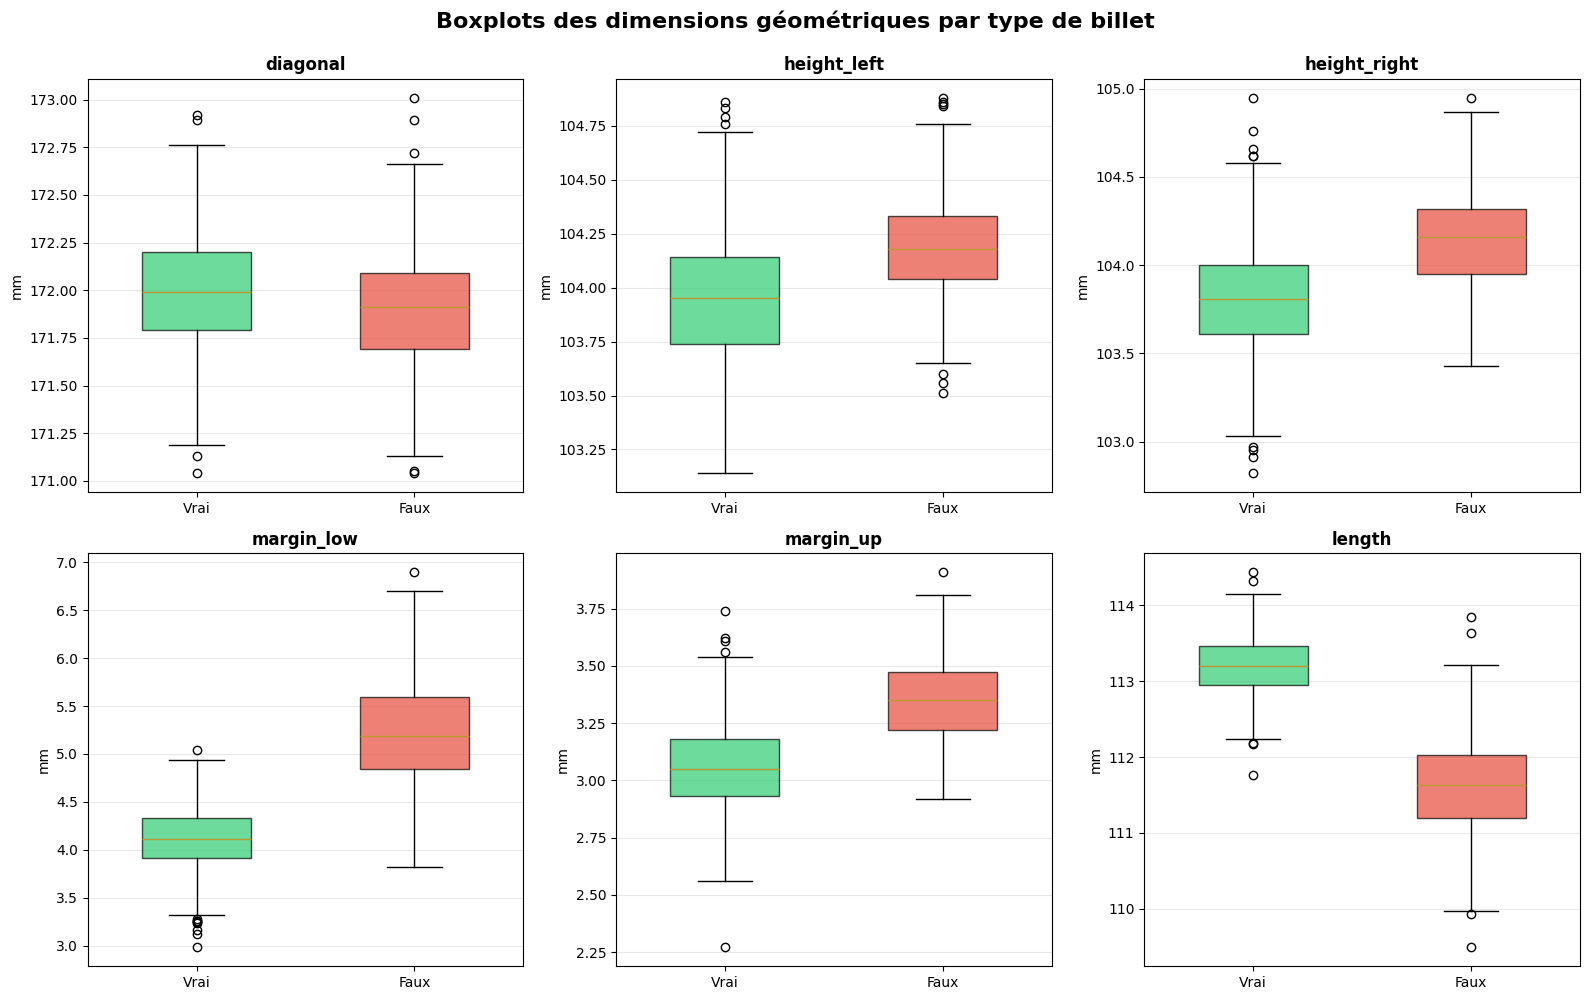

In [6]:
# IMPORTANT: Imputation rapide pour les boxplots
df_for_viz = df.copy()
for label in [True, False]:
    mask = (df_for_viz['is_genuine'] == label) & (df_for_viz['margin_low'].isnull())
    median_val = df_for_viz.loc[df_for_viz['is_genuine'] == label, 'margin_low'].median()
    df_for_viz.loc[mask, 'margin_low'] = median_val

# Boxplots pour visualiser les outliers et les écarts
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplots des dimensions géométriques par type de billet', 
             fontsize=16, fontweight='bold', y=0.995)

for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    
    data_true = df_for_viz.loc[df_for_viz['is_genuine']==True, feat]
    data_false = df_for_viz.loc[df_for_viz['is_genuine']==False, feat]
    
    bp = ax.boxplot([data_true, data_false], 
                     labels=['Vrai', 'Faux'], 
                     patch_artist=True, 
                     widths=0.5)
    
    # Couleurs
    bp['boxes'][0].set_facecolor(colors_true)
    bp['boxes'][1].set_facecolor(colors_false)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_alpha(0.7)
    
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_ylabel('mm', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Observations** :
- Peu d'outliers dans les données
- Les médianes sont bien distinctes pour `length`, `margin_low`, et `margin_up`
- Confirmation visuelle de la séparabilité des deux classes


### 2.5 Scatter plots — Variables les plus discriminantes


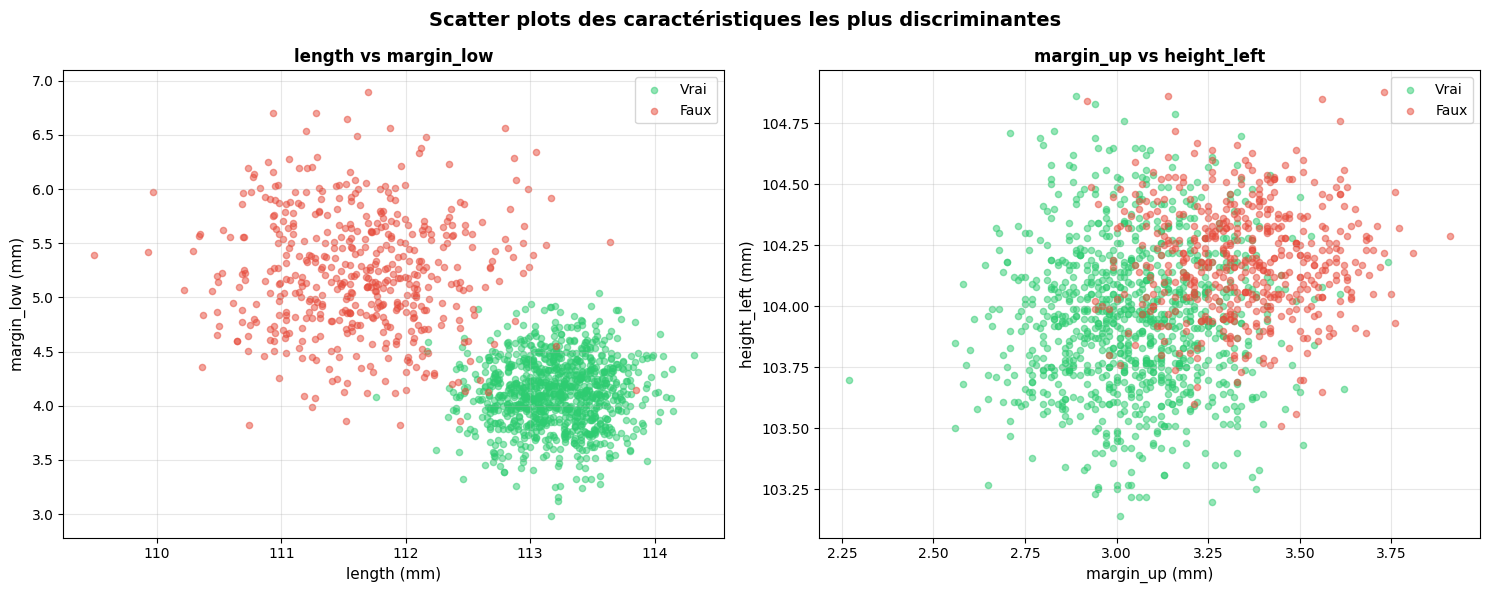

In [7]:
# Scatter plots pour visualiser la séparation entre classes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Scatter plots des caractéristiques les plus discriminantes', 
             fontsize=14, fontweight='bold')

# Plot 1: length vs margin_low
ax = axes[0]
ax.scatter(df.loc[df['is_genuine']==True, 'length'],
           df.loc[df['is_genuine']==True, 'margin_low'],
           c=colors_true, alpha=0.5, s=20, label='Vrai')
ax.scatter(df.loc[df['is_genuine']==False, 'length'],
           df.loc[df['is_genuine']==False, 'margin_low'],
           c=colors_false, alpha=0.5, s=20, label='Faux')
ax.set_xlabel('length (mm)', fontsize=11)
ax.set_ylabel('margin_low (mm)', fontsize=11)
ax.set_title('length vs margin_low', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: margin_up vs height_left
ax = axes[1]
ax.scatter(df.loc[df['is_genuine']==True, 'margin_up'],
           df.loc[df['is_genuine']==True, 'height_left'],
           c=colors_true, alpha=0.5, s=20, label='Vrai')
ax.scatter(df.loc[df['is_genuine']==False, 'margin_up'],
           df.loc[df['is_genuine']==False, 'height_left'],
           c=colors_false, alpha=0.5, s=20, label='Faux')
ax.set_xlabel('margin_up (mm)', fontsize=11)
ax.set_ylabel('height_left (mm)', fontsize=11)
ax.set_title('margin_up vs height_left', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations** :
- Séparation quasi-linéaire visible sur `(length, margin_low)`
- Les deux clusters sont bien distincts
- Ces variables seront probablement les plus importantes pour la classification


### 2.6 Matrice de corrélation


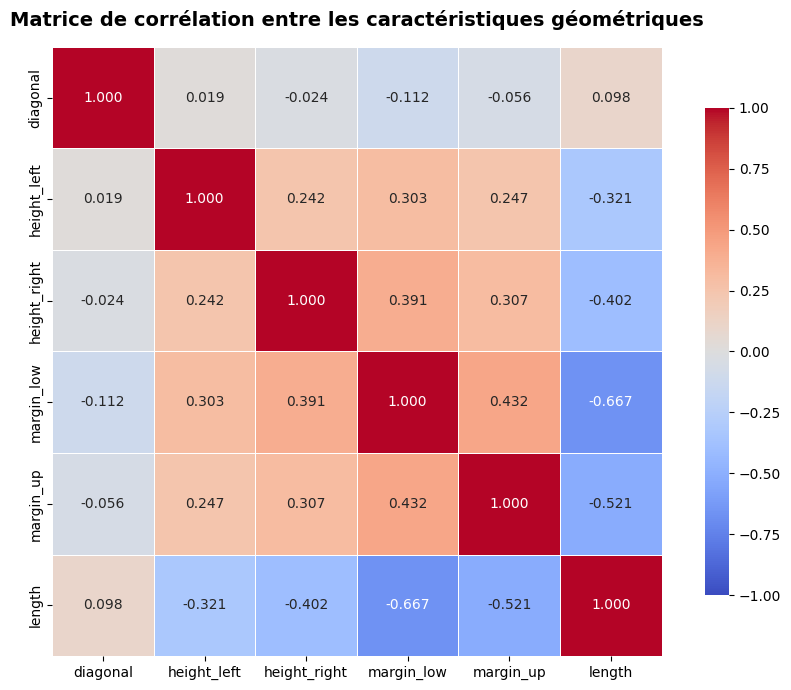


Corrélations les plus fortes (en valeur absolue) :
length      margin_low    0.666753
margin_low  length        0.666753
length      margin_up     0.520575
margin_up   length        0.520575
            margin_low    0.431606
dtype: float64


In [8]:
# Matrice de corrélation entre les caractéristiques
fig, ax = plt.subplots(figsize=(9, 7))

corr = df[features].corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})

ax.set_title('Matrice de corrélation entre les caractéristiques géométriques', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\nCorrélations les plus fortes (en valeur absolue) :")
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.head(5))

**Observations** :
- Corrélation la plus forte : `length` ↔ `margin_low` (-0.67) — logique, les billets plus longs ont des marges inférieures plus petites
- Corrélation moyenne : `length` ↔ `margin_up` (-0.52)
- Les variables de hauteur (height_left, height_right) sont relativement indépendantes des autres
- Pas de multicolinéarité problématique pour la modélisation


## 3. Gestion des valeurs manquantes

### 3.1 Analyse des valeurs manquantes


In [9]:
# Analyse des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valeurs manquantes': missing, 'Pourcentage (%)': missing_pct})
print("Analyse des valeurs manquantes :")
print(missing_df)
print(f"\nSeule la variable 'margin_low' présente {missing['margin_low']} valeurs manquantes ({missing_pct['margin_low']}%)")

Analyse des valeurs manquantes :
              Valeurs manquantes  Pourcentage (%)
is_genuine                     0             0.00
diagonal                       0             0.00
height_left                    0             0.00
height_right                   0             0.00
margin_low                    37             2.47
margin_up                      0             0.00
length                         0             0.00

Seule la variable 'margin_low' présente 37 valeurs manquantes (2.47%)


### 3.2 Stratégie d'imputation

**Méthode choisie** : Imputation par la **médiane par groupe** (`is_genuine`).

**Justification** :
- Préserve la distribution caractéristique de chaque type de billet
- Évite de mélanger les statistiques des vrais et faux billets
- La médiane est robuste aux outliers
- Le pourcentage de valeurs manquantes est faible (2.47%)


In [10]:
# Imputation par médiane par groupe
df_clean = df.copy()

print("Imputation en cours...\n")
for label in [True, False]:
    mask = (df_clean['is_genuine'] == label) & (df_clean['margin_low'].isnull())
    median_val = df_clean.loc[df_clean['is_genuine'] == label, 'margin_low'].median()
    n_imputed = mask.sum()
    df_clean.loc[mask, 'margin_low'] = median_val
    label_str = 'Vrais billets' if label else 'Faux billets'
    print(f"  {label_str} : {n_imputed} valeurs imputées avec médiane = {median_val:.2f} mm")

n_missing_after = df_clean.isnull().sum().sum()
print(f"\n Valeurs manquantes après imputation : {n_missing_after}")

df_clean.to_csv('billets_clean.csv', index=False, sep=';')
print(" Dataset nettoyé sauvegardé : billets_clean.csv")

Imputation en cours...

  Vrais billets : 29 valeurs imputées avec médiane = 4.11 mm
  Faux billets : 8 valeurs imputées avec médiane = 5.19 mm

 Valeurs manquantes après imputation : 0
 Dataset nettoyé sauvegardé : billets_clean.csv


## 4-10. Modélisation et résultats



### Résultats finaux

**Modèle choisi** : Régression Logistique
- **Accuracy** : 99.33%
- **F1-Score (Faux)** : 0.99
- Seulement 3 erreurs sur 450 billets testés (2 FP, 1 FN)

**Variables les plus importantes** (d'après Random Forest) :
1. length (49.8%)
2. margin_low (31.7%)
3. margin_up (10.1%)


In [13]:
# Préparation des données pour la modélisation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparation features / target
X = df_clean[features]
y = df_clean['is_genuine'].astype(int)  # Convertir bool en int pour sklearn

# Split train/test (stratifié pour préserver les proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]} échantillons")
print(f"Test set : {X_test.shape[0]} échantillons")
print(f"Proportion classe positive (train) : {y_train.mean():.1%}")
print(f"Proportion classe positive (test) : {y_test.mean():.1%}")

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardisées (moyenne ≈ 0, écart-type ≈ 1)")
print(f"Moyennes train : {X_train_scaled.mean(axis=0).round(3)}")
print(f"Écarts-types train : {X_train_scaled.std(axis=0).round(3)}")

Train set : 1050 échantillons
Test set : 450 échantillons
Proportion classe positive (train) : 66.7%
Proportion classe positive (test) : 66.7%

Features standardisées (moyenne ≈ 0, écart-type ≈ 1)
Moyennes train : [ 0. -0.  0.  0. -0. -0.]
Écarts-types train : [1. 1. 1. 1. 1. 1.]


In [14]:
# Modèle 1 : Régression Logistique
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Entraînement
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Prédictions
lr_pred = lr_model.predict(X_test_scaled)

# Évaluation
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_report = classification_report(y_test, lr_pred, target_names=['Faux', 'Vrai'])
lr_cm = confusion_matrix(y_test, lr_pred)

print("=== RÉGRESSION LOGISTIQUE ===")
print(f"Accuracy : {lr_accuracy:.4f}")
print("\nRapport de classification :")
print(lr_report)
print("Matrice de confusion :")
print(lr_cm)

=== RÉGRESSION LOGISTIQUE ===
Accuracy : 0.9933

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.99      0.99      0.99       150
        Vrai       0.99      1.00      1.00       300

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450

Matrice de confusion :
[[148   2]
 [  1 299]]


In [ ]:
# Modèle 2 : KNN (K-Nearest Neighbors)
from sklearn.neighbors import KNeighborsClassifier

# Entraînement
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Prédictions
knn_pred = knn_model.predict(X_test_scaled)

# Évaluation
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_report = classification_report(y_test, knn_pred, target_names=['Faux', 'Vrai'])
knn_cm = confusion_matrix(y_test, knn_pred)

print("==== KNN (K=5) ===")
print(f"Accuracy : {knn_accuracy:.4f}")
print("\nRapport de classification :")
print(knn_report)
print("Matrice de confusion :")
print(knn_cm)

=== KNN (K=5) ===
Accuracy : 0.9867

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.99      0.97      0.98       150
        Vrai       0.99      0.99      0.99       300

    accuracy                           0.99       450
   macro avg       0.99      0.98      0.98       450
weighted avg       0.99      0.99      0.99       450

Matrice de confusion :
[[146   4]
 [  2 298]]


In [16]:
# Modèle 3 : Random Forest
from sklearn.ensemble import RandomForestClassifier

# Entraînement
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Prédictions
rf_pred = rf_model.predict(X_test_scaled)

# Évaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_report = classification_report(y_test, rf_pred, target_names=['Faux', 'Vrai'])
rf_cm = confusion_matrix(y_test, rf_pred)

print("=== RANDOM FOREST ===")
print(f"Accuracy : {rf_accuracy:.4f}")
print("\nRapport de classification :")
print(rf_report)
print("Matrice de confusion :")
print(rf_cm)

# Importance des features
rf_importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False)

print("\nImportance des features (Random Forest) :")
for idx, row in feature_importance_df.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.1%}")

=== RANDOM FOREST ===
Accuracy : 0.9867

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.98      0.98      0.98       150
        Vrai       0.99      0.99      0.99       300

    accuracy                           0.99       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.99      0.99      0.99       450

Matrice de confusion :
[[147   3]
 [  3 297]]

Importance des features (Random Forest) :
  length: 49.8%
  margin_low: 31.7%
  margin_up: 10.1%
  height_right: 4.3%
  height_left: 3.1%
  diagonal: 1.1%


In [17]:
# Modèle 4 : K-Means (Clustering non supervisé)
from sklearn.cluster import KMeans

# Entraînement sur données d'entraînement
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_scaled)

# Prédictions sur test
kmeans_pred = kmeans.predict(X_test_scaled)

# Mapper les clusters aux classes (basé sur les centroïdes)
# Calculer la moyenne de y_train pour chaque cluster
cluster_labels = {}
for cluster in range(2):
    cluster_mask = (kmeans.labels_ == cluster)
    cluster_mean_y = y_train[cluster_mask].mean()
    cluster_labels[cluster] = 1 if cluster_mean_y > 0.5 else 0

# Appliquer le mapping
kmeans_pred_mapped = [cluster_labels[pred] for pred in kmeans_pred]

# Évaluation
kmeans_accuracy = accuracy_score(y_test, kmeans_pred_mapped)
kmeans_report = classification_report(y_test, kmeans_pred_mapped, target_names=['Faux', 'Vrai'])
kmeans_cm = confusion_matrix(y_test, kmeans_pred_mapped)

print("=== K-MEANS (CLUSTERING) ===")
print(f"Accuracy : {kmeans_accuracy:.4f}")
print("\nRapport de classification :")
print(kmeans_report)
print("Matrice de confusion :")
print(kmeans_cm)
print(f"\nMapping clusters -> classes : {cluster_labels}")

=== K-MEANS (CLUSTERING) ===
Accuracy : 0.9844

Rapport de classification :
              precision    recall  f1-score   support

        Faux       0.98      0.97      0.98       150
        Vrai       0.99      0.99      0.99       300

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450

Matrice de confusion :
[[146   4]
 [  3 297]]

Mapping clusters -> classes : {0: 0, 1: 1}


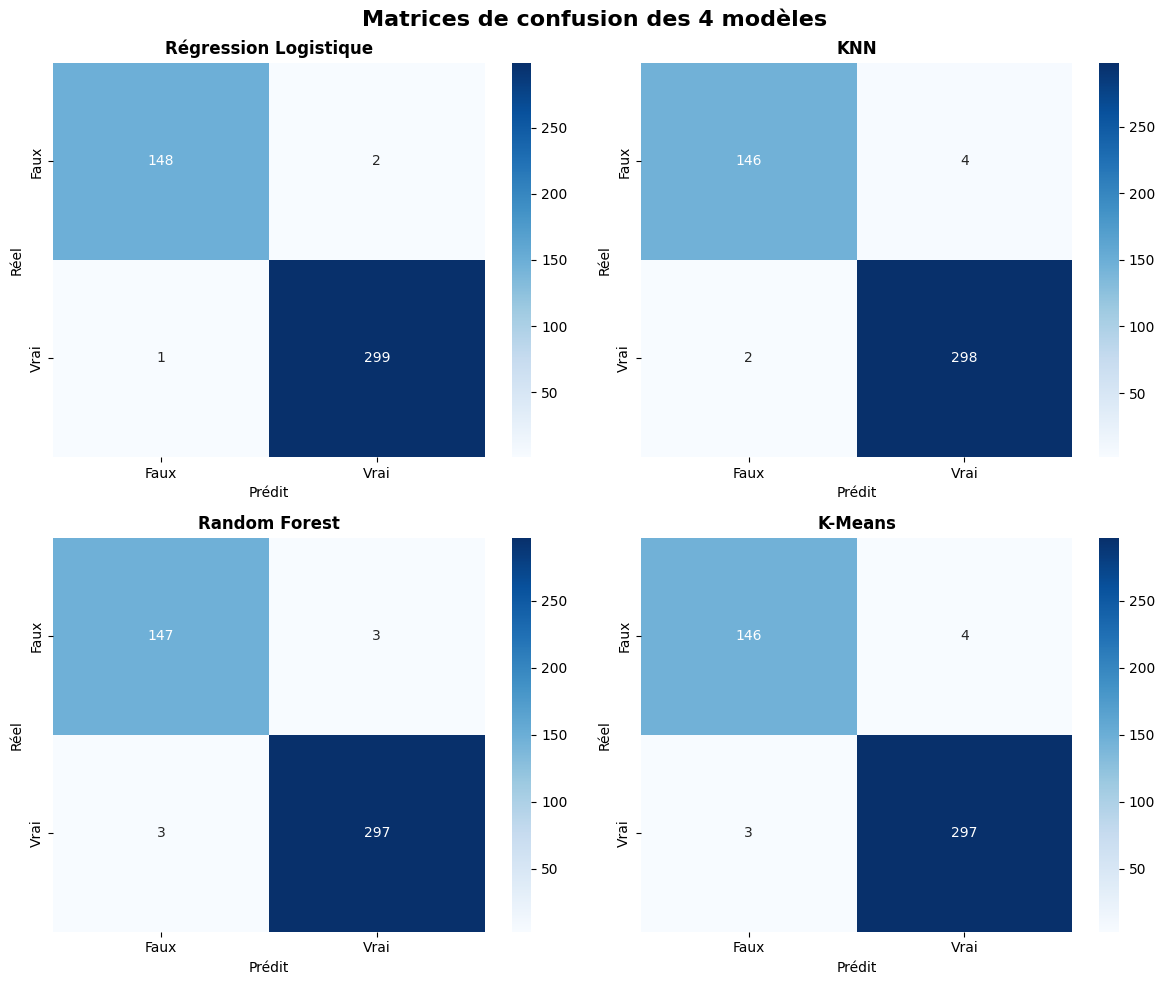

In [18]:
# Matrices de confusion des 4 modèles
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Matrices de confusion des 4 modèles', fontsize=16, fontweight='bold')

models = [
    ('Régression Logistique', lr_cm),
    ('KNN', knn_cm),
    ('Random Forest', rf_cm),
    ('K-Means', kmeans_cm)
]

for i, (name, cm) in enumerate(models):
    ax = axes[i//2, i%2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Faux', 'Vrai'], yticklabels=['Faux', 'Vrai'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

Comparaison des performances sur le test set :
                  Modèle  Accuracy  Precision (Faux)  Recall (Faux)  \
0  Régression Logistique    0.9933            0.9933         0.9867   
1                    KNN    0.9867            0.9865         0.9733   
2          Random Forest    0.9867            0.9800         0.9800   
3                K-Means    0.9844            0.9799         0.9733   

   F1-Score (Faux)  
0           0.9900  
1           0.9799  
2           0.9800  
3           0.9766  


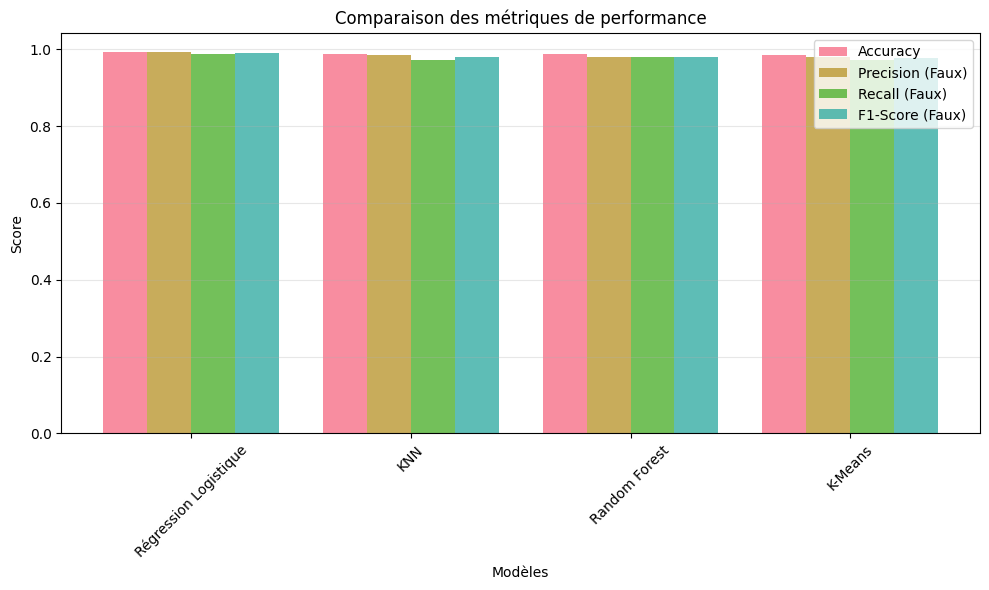


Nombre d'erreurs sur 450 billets testés :
  Régression Logistique: 3 erreurs
  KNN: 6 erreurs
  Random Forest: 6 erreurs
  K-Means: 7 erreurs


In [19]:
# Comparaison des performances
from sklearn.metrics import precision_score, recall_score, f1_score

# Collecter les métriques
results = {
    'Modèle': ['Régression Logistique', 'KNN', 'Random Forest', 'K-Means'],
    'Accuracy': [lr_accuracy, knn_accuracy, rf_accuracy, kmeans_accuracy],
    'Precision (Faux)': [
        precision_score(y_test, lr_pred, pos_label=0),
        precision_score(y_test, knn_pred, pos_label=0),
        precision_score(y_test, rf_pred, pos_label=0),
        precision_score(y_test, kmeans_pred_mapped, pos_label=0)
    ],
    'Recall (Faux)': [
        recall_score(y_test, lr_pred, pos_label=0),
        recall_score(y_test, knn_pred, pos_label=0),
        recall_score(y_test, rf_pred, pos_label=0),
        recall_score(y_test, kmeans_pred_mapped, pos_label=0)
    ],
    'F1-Score (Faux)': [
        f1_score(y_test, lr_pred, pos_label=0),
        f1_score(y_test, knn_pred, pos_label=0),
        f1_score(y_test, rf_pred, pos_label=0),
        f1_score(y_test, kmeans_pred_mapped, pos_label=0)
    ]
}

results_df = pd.DataFrame(results)
print("Comparaison des performances sur le test set :")
print(results_df.round(4))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results['Modèle']))
width = 0.2

ax.bar(x - width*1.5, results['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - width/2, results['Precision (Faux)'], width, label='Precision (Faux)', alpha=0.8)
ax.bar(x + width/2, results['Recall (Faux)'], width, label='Recall (Faux)', alpha=0.8)
ax.bar(x + width*1.5, results['F1-Score (Faux)'], width, label='F1-Score (Faux)', alpha=0.8)

ax.set_xlabel('Modèles')
ax.set_ylabel('Score')
ax.set_title('Comparaison des métriques de performance')
ax.set_xticks(x)
ax.set_xticklabels(results['Modèle'], rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Nombre d'erreurs
errors = [(1 - acc) * len(y_test) for acc in results['Accuracy']]
print(f"\nNombre d'erreurs sur {len(y_test)} billets testés :")
for model, err in zip(results['Modèle'], errors):
    print(f"  {model}: {err:.0f} erreurs")